In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
raw_data = pd.read_csv('/Users/garimau/dev/dsdp-ucsf/UCSFDelirium/Demographic/oversampled_demographic.csv')

In [3]:
X = raw_data.drop(columns=['target'], inplace=False)
y = raw_data['target']

In [6]:
import shap
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize Numerical Features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)



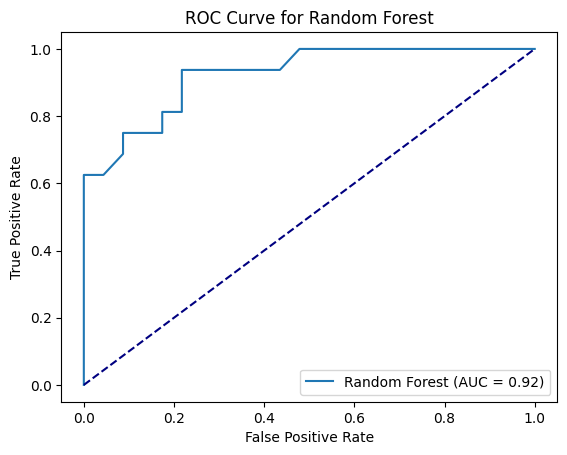

ROC AUC Score: 0.92
Accuracy: 0.82
Confusion Matrix:
[[18  5]
 [ 2 14]]


In [7]:
# Step 5: Train Random Forest Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, confusion_matrix

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# Step 6: Make Predictions and Evaluate Model
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
y_pred = rf_model.predict(X_test)

# Calculate AUC-ROC score
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Step 7: Plot the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest')
plt.legend(loc='lower right')
plt.show()

# Step 8: Output Additional Metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'ROC AUC Score: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:')
print(conf_matrix)

In [8]:
raw_data.head()
raw_data.columns
raw_data['Race_American Indian / Alaska Native'] = raw_data['Race_American Indian / Alaska Native'].map(int)
raw_data["Race_Asian"] = raw_data["Race_Asian"].map(int)
raw_data["Race_Black / African American"] = raw_data["Race_Black / African American"].map(int)
raw_data["Race_Native Hawaiian / Other Pacific Islander"] = raw_data["Race_Native Hawaiian / Other Pacific Islander"].map(int)
raw_data["Race_Other / Multiple Races"] = raw_data["Race_Other / Multiple Races"].map(int)
raw_data["Race_Unknown"] = raw_data["Race_Unknown"].map(int)
raw_data["Race_White"] = raw_data["Race_White"].map(int)
raw_data["target"] = raw_data["target"].map(int)
raw_data["Hispanic ethnicity"] = raw_data["Hispanic ethnicity"].map(int)
raw_data.head()



,Age at Admission,Sex at Birth,Hispanic ethnicity,SOFA,WHO Scale,Race_American Indian / Alaska Native,Race_Asian,Race_Black / African American,Race_Native Hawaiian / Other Pacific Islander,Race_Other / Multiple Races,Race_Unknown,Race_White,target
0,35,1,0,10,7,0,0,0,0,0,0,1,1
1,44,1,0,4,5,0,0,0,0,1,0,0,0
2,84,0,0,0,3,0,0,0,1,0,0,0,1
3,67,0,0,9,7,0,0,0,0,0,0,1,0
4,51,1,0,10,7,0,0,1,0,0,0,0,0


<Figure size 640x480 with 0 Axes>

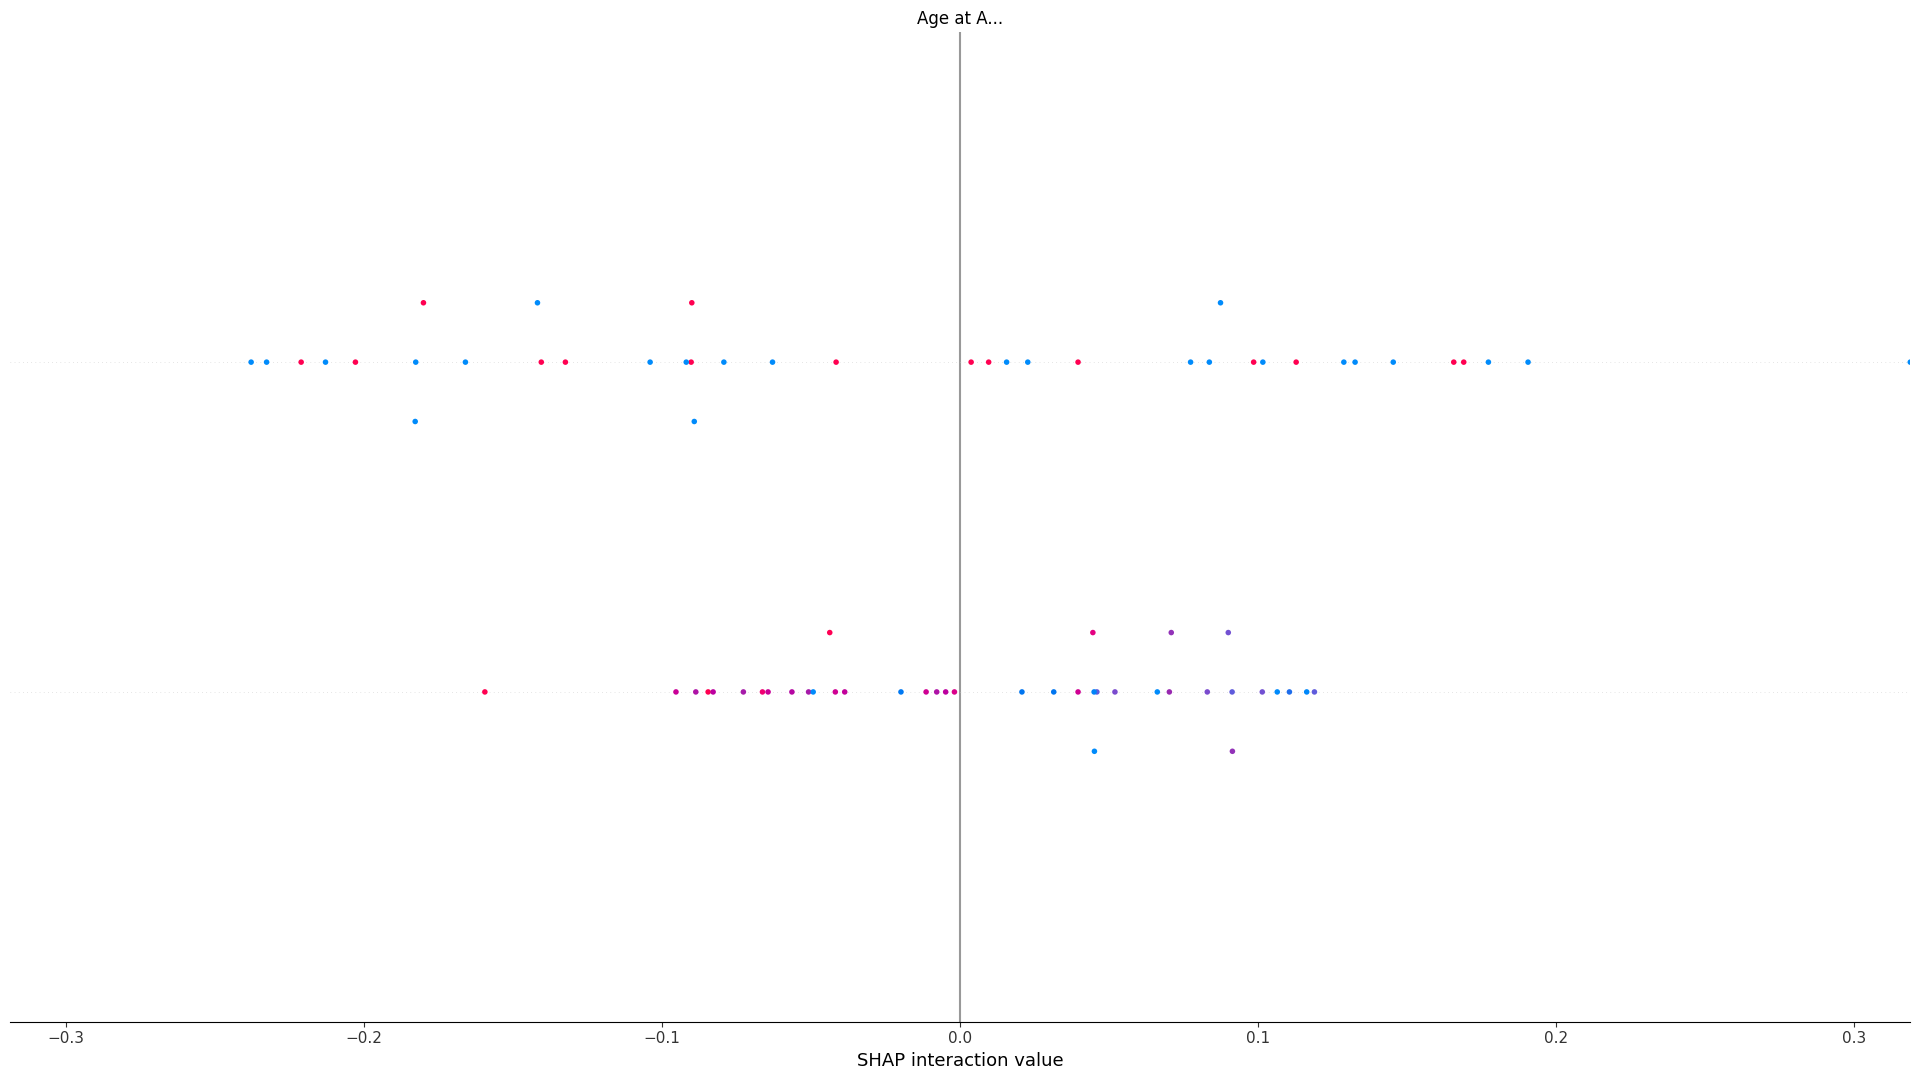

In [9]:
import shap
import matplotlib.pyplot as plt

# Ensure model is trained
rf_model.fit(X_train, y_train)

# Create SHAP explainer for the trained model
explainer = shap.Explainer(rf_model, X_train)

# Compute SHAP values on test set
shap_values = explainer(X_test)

# Plot SHAP summary showing ALL features
shap.summary_plot(
    shap_values.values,              # Use only main effects (not interaction matrix)
    X_test,                          # Use DataFrame to retain feature names
    feature_names=X_test.columns,   # Explicitly provide feature names
    plot_type="dot",                # Dot plot (you can change to "bar" if you want)
    max_display=len(X_test.columns),  # Show all features
    show=True
)

In [10]:
X = raw_data.drop(columns=['target'], inplace=False)
y = raw_data['target']